# FXPM Order-Management Proof of Concept

This notebook tests a narrow question in a controlled way: does an active order-management layer improve an existing FXPM strategy relative to the current fixed stop-loss / take-profit baseline?

Design principles:
- Keep entry logic constant.
- Keep data, spread, slippage, commission, and sizing constant.
- Change only post-entry governance.
- Include random-entry sanity checks where the order-management rule itself is price-path-based and does not reuse the strategy's predictive state.

What this revision adds:
- **Calculation-accuracy audit.** The managed replay is verified byte-for-byte against `Backtester.run` via a control-arm parity assertion. Per-trade MFE/MAE is now tracked and exposed in the diagnostics cell.
- **Safer same-bar re-entry.** Signal-invalidation exits are only allowed to re-enter on the same bar when the generator signal on bar `i-1` actually flipped to the opposite side. Previously the guard only checked the strategy's continuous support state, which could allow a same-direction re-entry.
- **Research-backed additions:** `chandelier_exit`, `r_ladder_lock`, `profit_giveback_exit`, `hard_time_exit`, `donchian_trail` (see citations in cell 1).
- **Enriched diagnostics:** exit-reason breakdown per arm, MFE/MAE summary per arm, bootstrap 95% confidence intervals on the strategy uplift, and an edge-retention score that subtracts the mean random-entry uplift from the strategy uplift.

POC scope:
- Baseline strategy: `KaufmanAMATrendStrategy` as already present in `pm_configs.json`.
- Symbols: `EURUSD` and `NZDJPY` on `H4`.
- Data: recent local history only, resampled from the project `data/` directory.
- The goal is not to prove one universal exit rule, but to rank promising governance overlays and decide which deserve broader validation.


In [1]:
from dataclasses import dataclass, field
from pathlib import Path
import json
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from pm_core import Backtester, DataLoader, FeatureComputer, PipelineConfig, get_instrument_spec
from pm_enhancement_seams import ExitPackContext, MarketDrivenExitPack
from pm_strategies import StrategyRegistry

pd.options.display.max_columns = 200
pd.options.display.width = 180
pd.options.display.float_format = lambda value: f"{value:,.4f}"
plt.style.use("seaborn-v0_8-whitegrid")

REPO_ROOT = Path.cwd()
DATA_DIR = REPO_ROOT / "data"
PM_CONFIGS_PATH = REPO_ROOT / "pm_configs.json"

SYMBOLS = ["EURUSD", "NZDJPY"]
TIMEFRAME = "H4"
BASE_TIMEFRAME = "M5"
BAR_COUNT = 1200
RANDOM_SEEDS = list(range(40))
BOOTSTRAP_ITERATIONS = 1000
BOOTSTRAP_SEED = 17

ARM_POLICIES = {
    "control_fixed": {
        "label": "Control: fixed SL/TP",
    },
    "breakeven_1r": {
        "label": "1R breakeven",
        "use_breakeven": True,
        "breakeven_trigger_r": 1.0,
        "breakeven_offset_pips": 0.0,
    },
    "atr_trail_capped": {
        "label": "ATR trail + fixed TP",
        "use_atr_trail": True,
        "atr_trail_mult": 2.5,
        "atr_trail_activation_mult": 1.5,
    },
    "be_plus_atr_runner": {
        "label": "1R breakeven + ATR runner",
        "use_breakeven": True,
        "breakeven_trigger_r": 1.0,
        "breakeven_offset_pips": 0.0,
        "use_atr_trail": True,
        "atr_trail_mult": 2.5,
        "atr_trail_activation_mult": 1.5,
        "release_tp_after_r": 1.0,
    },
    "signal_invalidation_exit": {
        "label": "Signal invalidation after 0.5R",
        "exit_on_support_invalidation": True,
        "support_invalidation_after_r": 0.5,
        "support_invalidation_min_bars": 3,
    },
    "stagnation_time_stop": {
        "label": "8-bar stale-trade exit",
        "stagnation_bars": 8,
        "stagnation_min_mfe_r": 0.5,
        "stagnation_exit_only_if_nonpositive": True,
    },
    "two_leg_scaleout_runner": {
        "label": "50/50 scale-out runner",
        "two_leg_scaleout": True,
        "scaleout_fraction": 0.5,
        "scaleout_target_r": 1.0,
        "use_breakeven": True,
        "breakeven_trigger_r": 1.0,
        "breakeven_offset_pips": 0.0,
        "use_atr_trail": True,
        "atr_trail_mult": 2.5,
        "atr_trail_activation_mult": 1.5,
    },
    "trend_decay_runner": {
        "label": "Trend-decay runner",
        "use_breakeven": True,
        "breakeven_trigger_r": 1.0,
        "breakeven_offset_pips": 0.0,
        "use_atr_trail": True,
        "atr_trail_mult": 2.5,
        "atr_trail_activation_mult": 1.5,
        "release_tp_after_r": 1.0,
        "exit_on_support_invalidation": True,
        "support_invalidation_after_r": 1.0,
        "support_invalidation_min_bars": 3,
    },
    "volatility_shock_exit": {
        "label": "ATR shock exit",
        "shock_range_atr": 2.75,
        "shock_adverse_close_frac": 0.35,
        "shock_loss_r_threshold": 0.25,
    },
    "chandelier_exit": {
        "label": "Chandelier N=22 trail",
        "use_chandelier": True,
        "chandelier_lookback": 22,
        "chandelier_atr_mult": 3.0,
        "chandelier_activation_r": 0.5,
    },
    "r_ladder_lock": {
        "label": "R-ladder lock (1R/2R/3R)",
        "use_breakeven": True,
        "breakeven_trigger_r": 1.0,
        "breakeven_offset_pips": 0.0,
        "r_ladder_levels": [[2.0, 1.0], [3.0, 2.0], [4.0, 3.0]],
    },
    "profit_giveback_exit": {
        "label": "35% profit give-back",
        "use_breakeven": True,
        "breakeven_trigger_r": 1.0,
        "breakeven_offset_pips": 0.0,
        "profit_giveback_activation_r": 1.0,
        "profit_giveback_fraction": 0.35,
    },
    "hard_time_exit": {
        "label": "24-bar hard time exit",
        "hard_time_bars": 24,
    },
    "donchian_trail": {
        "label": "Donchian N=20 trail",
        "use_donchian_trail": True,
        "donchian_lookback": 20,
        "donchian_activation_r": 0.5,
    },
}

RANDOM_TEST_ARMS = [
    "breakeven_1r",
    "atr_trail_capped",
    "be_plus_atr_runner",
    "stagnation_time_stop",
    "two_leg_scaleout_runner",
    "volatility_shock_exit",
    "chandelier_exit",
    "r_ladder_lock",
    "profit_giveback_exit",
    "hard_time_exit",
    "donchian_trail",
]

MODEL_STATE_ARMS = [
    "signal_invalidation_exit",
    "trend_decay_runner",
]

pipeline_config = PipelineConfig(data_dir=DATA_DIR)
pipeline_config.position_size_pct = pipeline_config.risk_per_trade_pct

with PM_CONFIGS_PATH.open("r", encoding="utf-8") as fh:
    pm_configs = json.load(fh)

baseline_rows = []
for symbol in SYMBOLS:
    cfg = pm_configs[symbol]
    baseline_rows.append(
        {
            "symbol": symbol,
            "strategy_name": cfg["strategy_name"],
            "timeframe": cfg["timeframe"],
            "parameters": cfg["parameters"],
            "valid_until": cfg.get("valid_until"),
            "optimized_at": cfg.get("optimized_at"),
        }
    )

baseline_refs_df = pd.DataFrame(baseline_rows)
display(baseline_refs_df)

BASELINE_STRATEGY_NAME = baseline_rows[0]["strategy_name"]
BASELINE_PARAMS = dict(baseline_rows[0]["parameters"])

if not all(row["strategy_name"] == BASELINE_STRATEGY_NAME for row in baseline_rows):
    raise ValueError("Selected symbols do not share the same baseline strategy.")
if not all(row["timeframe"] == TIMEFRAME for row in baseline_rows):
    raise ValueError("Selected symbols do not share the requested timeframe.")

display(
    Markdown(
        f"**Baseline for the POC:** `{BASELINE_STRATEGY_NAME}` on `{TIMEFRAME}` with parameters `{BASELINE_PARAMS}`."
    )
)

research_lines = [
    "## Research-informed candidate families",
    "",
    "Directly motivating references used for this notebook revision:",
    "- Stop-loss rules can help when return dynamics have momentum or regime structure, but can harm when stops are too tight: [Kaminski & Lo (2007)](https://ssrn.com/abstract=968338), [Lo & Remorov (2015)](https://ssrn.com/abstract=2695383).",
    "- Trailing stops are strong candidates, and the combination of a trailing stop with a limit-style exit is analytically meaningful: [Leung & Zhang (2019)](https://ssrn.com/abstract=2895437).",
    "- Trailing stop-loss rules often improve downside control and risk-adjusted outcomes even when raw mean return is mixed: [Dai et al. (2019)](https://ssrn.com/abstract=3338243).",
    "- Abnormal price-jump or volatility-shock exits are viable overlays for algorithmic trading systems: [Koegelenberg & van Vuuren (2023)](https://ssrn.com/abstract=4374887).",
    "- Maximum-horizon and hard-threshold style exits are technically implementable in live systems: [Veiga & Shelton (2024)](https://ssrn.com/abstract=4947910).",
    "- Channel-break and Chandelier-style fixed-lookback trails are long-standing systematic practice: Chuck LeBeau (1992/1997) Chandelier Exit, and Faith (2007) *Way of the Turtle* (Donchian break exit, profit give-back trail).",
    "- Progressive profit-lock ladders (lock breakeven at 1R, 1R at 2R, and so on) are a standard risk-engineering technique covered in Van Tharp (1998) and Elder (1993).",
    "",
    "Arm classification:",
    "- **Model-state overlays** (use the baseline strategy's own support state after entry, intentionally excluded from random-entry controls): `signal_invalidation_exit`, `trend_decay_runner`.",
    "- **Price-path overlays** (sanity-checked against random entries): `breakeven_1r`, `atr_trail_capped`, `be_plus_atr_runner`, `stagnation_time_stop`, `two_leg_scaleout_runner`, `volatility_shock_exit`, `chandelier_exit`, `r_ladder_lock`, `profit_giveback_exit`, `hard_time_exit`, `donchian_trail`.",
]
display(Markdown("\n".join(research_lines)))


,symbol,strategy_name,timeframe,parameters,valid_until,optimized_at
0,EURUSD,KaufmanAMATrendStrategy,H4,"{'er_period': 10, 'fast_period': 2, 'slow_peri...",2026-04-12T00:01:00,2026-03-30T12:28:13.998568
1,NZDJPY,KaufmanAMATrendStrategy,H4,"{'er_period': 10, 'fast_period': 2, 'slow_peri...",2026-04-12T00:01:00,2026-03-30T16:58:03.872723


**Baseline for the POC:** `KaufmanAMATrendStrategy` on `H4` with parameters `{'er_period': 10, 'fast_period': 2, 'slow_period': 30, 'signal_mode': 'direction', 'sl_atr_mult': 2.0, 'tp_atr_mult': 3.0}`.

## Research-informed candidate families

Directly motivating references used for this notebook revision:
- Stop-loss rules can help when return dynamics have momentum or regime structure, but can harm when stops are too tight: [Kaminski & Lo (2007)](https://ssrn.com/abstract=968338), [Lo & Remorov (2015)](https://ssrn.com/abstract=2695383).
- Trailing stops are strong candidates, and the combination of a trailing stop with a limit-style exit is analytically meaningful: [Leung & Zhang (2019)](https://ssrn.com/abstract=2895437).
- Trailing stop-loss rules often improve downside control and risk-adjusted outcomes even when raw mean return is mixed: [Dai et al. (2019)](https://ssrn.com/abstract=3338243).
- Abnormal price-jump or volatility-shock exits are viable overlays for algorithmic trading systems: [Koegelenberg & van Vuuren (2023)](https://ssrn.com/abstract=4374887).
- Maximum-horizon and hard-threshold style exits are technically implementable in live systems: [Veiga & Shelton (2024)](https://ssrn.com/abstract=4947910).
- Channel-break and Chandelier-style fixed-lookback trails are long-standing systematic practice: Chuck LeBeau (1992/1997) Chandelier Exit, and Faith (2007) *Way of the Turtle* (Donchian break exit, profit give-back trail).
- Progressive profit-lock ladders (lock breakeven at 1R, 1R at 2R, and so on) are a standard risk-engineering technique covered in Van Tharp (1998) and Elder (1993).

Arm classification:
- **Model-state overlays** (use the baseline strategy's own support state after entry, intentionally excluded from random-entry controls): `signal_invalidation_exit`, `trend_decay_runner`.
- **Price-path overlays** (sanity-checked against random entries): `breakeven_1r`, `atr_trail_capped`, `be_plus_atr_runner`, `stagnation_time_stop`, `two_leg_scaleout_runner`, `volatility_shock_exit`, `chandelier_exit`, `r_ladder_lock`, `profit_giveback_exit`, `hard_time_exit`, `donchian_trail`.

In [2]:
@dataclass
class ManagedPosition:
    signal_bar: int
    entry_bar: int
    direction: int
    entry_price: float
    stop_loss: float
    take_profit: float
    initial_stop_loss: float
    initial_take_profit: float
    position_size: float
    risk_amount: float
    highest_since_entry: float
    lowest_since_entry: float
    active_stop_label: str = "FIXED_SL"
    metadata: dict = field(default_factory=dict)


def build_strategy(strategy_name: str, params: dict):
    return StrategyRegistry.get(strategy_name, **params)


def compute_support_state(strategy, features: pd.DataFrame) -> pd.Series:
    """
    Continuous support state used by model-state overlays.

    For the trend generator this is the sign of the AMA direction / price-vs-AMA
    relation. We intentionally produce a *continuous* series rather than the
    transient generator signal (which only fires on flips), so that overlays
    can ask "is the trend still backing this position?" on any bar.
    """
    if getattr(strategy, "name", "") == "KaufmanAMATrendStrategy":
        er_p = int(strategy.params.get("er_period", 10))
        fast_p = int(strategy.params.get("fast_period", 2))
        slow_p = int(strategy.params.get("slow_period", 30))
        mode = str(strategy.params.get("signal_mode", "direction"))
        close = features["Close"].to_numpy(dtype=float)
        ama = strategy._kaufman_ama(close, er_p, fast_p, slow_p)
        ama_s = pd.Series(ama, index=features.index)
        support = pd.Series(0, index=features.index, dtype=int)
        if mode == "crossover":
            support[features["Close"] > ama_s] = 1
            support[features["Close"] < ama_s] = -1
        else:
            ama_diff = ama_s.diff()
            support[ama_diff > 0] = 1
            support[ama_diff < 0] = -1
        return support.astype(int)

    signals = strategy.generate_signals(features, "")
    fallback = pd.Series(signals, index=features.index).replace(0, np.nan).ffill().fillna(0)
    return fallback.astype(int)


def load_symbol_payload(symbol: str, strategy_name: str, params: dict, timeframe: str, bar_count: int):
    loader = DataLoader(DATA_DIR)
    strategy = build_strategy(strategy_name, params)
    min_required = max(int(bar_count * 0.6), int(getattr(strategy, "MIN_BARS", 0)) + 80)
    features_base = loader.get_recent_data(
        symbol,
        timeframe,
        count=bar_count,
        min_required=min_required,
        base_timeframe=BASE_TIMEFRAME,
    )
    if features_base is None or len(features_base) == 0:
        raise ValueError(f"No data available for {symbol} {timeframe}")
    features = FeatureComputer.compute_required(
        features_base,
        strategy.get_feature_request(),
        symbol=symbol,
        timeframe=timeframe,
    )
    if "ATR_14" not in features.columns:
        raise ValueError(
            f"ATR_14 missing from features for {symbol} {timeframe}. "
            "Order management overlays require ATR to be available."
        )
    signals = strategy.generate_signals(features, symbol).astype(int)
    support_state = compute_support_state(strategy, features)
    warmup_bars = max(int(getattr(strategy, "MIN_BARS", 0)), 60)
    return {
        "symbol": symbol,
        "timeframe": timeframe,
        "strategy": strategy,
        "features": features,
        "signals": signals,
        "support_state": support_state,
        "spec": get_instrument_spec(symbol),
        "warmup_bars": warmup_bars,
    }


def build_entry_arrays(features, signals, symbol, strategy, spec, config, warmup_bars=0):
    n_bars = len(features)
    entry_prices = np.full(n_bars, np.nan, dtype=float)
    sl_prices = np.full(n_bars, np.nan, dtype=float)
    tp_prices = np.full(n_bars, np.nan, dtype=float)
    open_arr = features["Open"].to_numpy(dtype=float)
    half_spread = spec.get_half_spread_price() if config.use_spread else 0.0

    for entry_bar in range(max(1, warmup_bars), n_bars):
        signal_bar = entry_bar - 1
        direction = int(signals.iat[signal_bar])
        if direction == 0:
            continue
        sl_pips, tp_pips = strategy.calculate_stops(
            features,
            direction,
            symbol,
            spec=spec,
            bar_index=signal_bar,
        )
        if not np.isfinite(sl_pips) or not np.isfinite(tp_pips) or sl_pips <= 0 or tp_pips <= 0:
            raise ValueError(
                f"Invalid stop calculation for {symbol} at bar {signal_bar}: sl={sl_pips}, tp={tp_pips}"
            )
        open_price = float(open_arr[entry_bar])
        if config.use_spread:
            entry_price = open_price + half_spread if direction == 1 else open_price - half_spread
        else:
            entry_price = open_price
        if direction == 1:
            stop_loss = entry_price - spec.pips_to_price(sl_pips)
            take_profit = entry_price + spec.pips_to_price(tp_pips)
        else:
            stop_loss = entry_price + spec.pips_to_price(sl_pips)
            take_profit = entry_price - spec.pips_to_price(tp_pips)
        entry_prices[entry_bar] = entry_price
        sl_prices[entry_bar] = stop_loss
        tp_prices[entry_bar] = take_profit

    return entry_prices, sl_prices, tp_prices


def precompute_rolling_levels(features: pd.DataFrame, lookbacks):
    """
    Rolling high/low lookbacks used by Chandelier and Donchian overlays.

    We shift by 1 so that an overlay reading `level.iat[prev_bar]` on bar `i`
    only sees information through bar `i-1` (strict causality).
    """
    out = {}
    for n in lookbacks:
        if n <= 0:
            continue
        high_key = f"roll_high_{n}"
        low_key = f"roll_low_{n}"
        if high_key not in out:
            out[high_key] = features["High"].rolling(int(n), min_periods=1).max().shift(1)
        if low_key not in out:
            out[low_key] = features["Low"].rolling(int(n), min_periods=1).min().shift(1)
    return out


def tighten_stop(position: ManagedPosition, new_stop: float, label: str):
    """Only ever tightens the stop. Ignores non-finite inputs."""
    if not np.isfinite(new_stop):
        return
    if position.direction == 1 and new_stop > position.stop_loss:
        position.stop_loss = float(new_stop)
        position.active_stop_label = label
    elif position.direction == -1 and new_stop < position.stop_loss:
        position.stop_loss = float(new_stop)
        position.active_stop_label = label


def apply_policy(position: ManagedPosition, current_bar: int, features: pd.DataFrame, signals: pd.Series, support_state: pd.Series, spec, policy: dict, rolling_levels: dict):
    """
    Evaluate the governance policy on bar `current_bar` using information
    through bar `current_bar - 1` (strict causality).

    Returns either None (stay in the position and apply any stop tightening
    inline) or a dict with `exit_at_open=True` and an exit reason if the
    policy requires flattening at the next bar's open.
    """
    if current_bar <= 0:
        return None
    prev_bar = current_bar - 1
    if prev_bar < position.entry_bar:
        return None

    prev_close = float(features["Close"].iat[prev_bar])
    prev_high = float(features["High"].iat[prev_bar])
    prev_low = float(features["Low"].iat[prev_bar])

    position.highest_since_entry = max(position.highest_since_entry, prev_high)
    position.lowest_since_entry = min(position.lowest_since_entry, prev_low)

    initial_r = abs(position.entry_price - position.initial_stop_loss)
    if initial_r <= 0:
        return None

    bars_held = current_bar - position.entry_bar
    if position.direction == 1:
        favorable_move = position.highest_since_entry - position.entry_price
        adverse_move = position.entry_price - position.lowest_since_entry
        unrealized_r_close = (prev_close - position.entry_price) / initial_r
    else:
        favorable_move = position.entry_price - position.lowest_since_entry
        adverse_move = position.highest_since_entry - position.entry_price
        unrealized_r_close = (position.entry_price - prev_close) / initial_r
    favorable_r = favorable_move / initial_r
    adverse_r = adverse_move / initial_r

    # Persist MFE/MAE in R so the closing code can attach them to the trade
    # record for diagnostics. Favorable is already strictly non-negative.
    position.metadata["max_fav_r"] = max(float(position.metadata.get("max_fav_r", 0.0)), float(favorable_r))
    position.metadata["max_adv_r"] = max(float(position.metadata.get("max_adv_r", 0.0)), float(adverse_r))

    atr_value = float(features["ATR_14"].iat[prev_bar]) if "ATR_14" in features.columns else float("nan")

    if policy.get("use_breakeven"):
        trigger_r = float(policy.get("breakeven_trigger_r", 1.0))
        offset_price = spec.pips_to_price(float(policy.get("breakeven_offset_pips", 0.0)))
        if favorable_r >= trigger_r:
            if position.direction == 1:
                tighten_stop(position, position.entry_price + offset_price, "BREAKEVEN_STOP")
            else:
                tighten_stop(position, position.entry_price - offset_price, "BREAKEVEN_STOP")

    for trigger_r, lock_r in policy.get("r_ladder_levels", []):
        if favorable_r >= float(trigger_r):
            if position.direction == 1:
                tighten_stop(position, position.entry_price + float(lock_r) * initial_r, f"R_LOCK_{lock_r:g}R")
            else:
                tighten_stop(position, position.entry_price - float(lock_r) * initial_r, f"R_LOCK_{lock_r:g}R")

    release_tp_after_r = policy.get("release_tp_after_r")
    if release_tp_after_r is not None and not position.metadata.get("tp_released"):
        if favorable_r >= float(release_tp_after_r):
            position.take_profit = math.inf if position.direction == 1 else -math.inf
            position.metadata["tp_released"] = True

    if policy.get("use_atr_trail") and np.isfinite(atr_value) and atr_value > 0:
        exit_pack = MarketDrivenExitPack(
            atr_trail_mult=float(policy.get("atr_trail_mult", 2.5)),
            atr_trail_activation_mult=float(policy.get("atr_trail_activation_mult", 1.5)),
            partial_tp1_mult=1e9,
            partial_tp1_close_pct=0.0,
            breakeven_trigger_mult=1e9,
            breakeven_offset_pips=0.0,
            enabled=True,
        )
        decision = exit_pack.evaluate(
            ExitPackContext(
                symbol=position.metadata["symbol"],
                timeframe=position.metadata["timeframe"],
                direction="LONG" if position.direction == 1 else "SHORT",
                entry_price=position.entry_price,
                current_price=prev_close,
                current_atr=atr_value,
                bars_held=bars_held,
                highest_since_entry=position.highest_since_entry,
                lowest_since_entry=position.lowest_since_entry,
                position_size=position.position_size,
                features=features,
                metadata=position.metadata,
            )
        )
        if decision.stop_loss is not None:
            tighten_stop(position, float(decision.stop_loss), "ATR_TRAIL_STOP")

    if policy.get("use_chandelier") and np.isfinite(atr_value) and atr_value > 0:
        lookback = int(policy.get("chandelier_lookback", 22))
        mult = float(policy.get("chandelier_atr_mult", 3.0))
        activation_r = float(policy.get("chandelier_activation_r", 0.5))
        if favorable_r >= activation_r:
            high_series = rolling_levels.get(f"roll_high_{lookback}")
            low_series = rolling_levels.get(f"roll_low_{lookback}")
            if high_series is not None and low_series is not None:
                if position.direction == 1:
                    ref_high = float(high_series.iat[prev_bar])
                    if np.isfinite(ref_high):
                        tighten_stop(position, ref_high - mult * atr_value, "CHANDELIER_STOP")
                else:
                    ref_low = float(low_series.iat[prev_bar])
                    if np.isfinite(ref_low):
                        tighten_stop(position, ref_low + mult * atr_value, "CHANDELIER_STOP")

    if policy.get("use_donchian_trail"):
        lookback = int(policy.get("donchian_lookback", 20))
        activation_r = float(policy.get("donchian_activation_r", 0.5))
        if favorable_r >= activation_r:
            high_series = rolling_levels.get(f"roll_high_{lookback}")
            low_series = rolling_levels.get(f"roll_low_{lookback}")
            if high_series is not None and low_series is not None:
                if position.direction == 1:
                    ref_low = float(low_series.iat[prev_bar])
                    if np.isfinite(ref_low):
                        tighten_stop(position, ref_low, "DONCHIAN_STOP")
                else:
                    ref_high = float(high_series.iat[prev_bar])
                    if np.isfinite(ref_high):
                        tighten_stop(position, ref_high, "DONCHIAN_STOP")

    profit_giveback_activation_r = policy.get("profit_giveback_activation_r")
    if profit_giveback_activation_r is not None:
        giveback_fraction = float(policy.get("profit_giveback_fraction", 0.35))
        activation_r = float(profit_giveback_activation_r)
        if favorable_r >= activation_r and giveback_fraction > 0.0:
            peak_favorable_price = position.highest_since_entry if position.direction == 1 else position.lowest_since_entry
            max_favorable_distance = favorable_r * initial_r
            retained_distance = max_favorable_distance * (1.0 - giveback_fraction)
            if position.direction == 1:
                tighten_stop(position, position.entry_price + retained_distance, "GIVEBACK_STOP")
            else:
                tighten_stop(position, position.entry_price - retained_distance, "GIVEBACK_STOP")
            _ = peak_favorable_price  # reserved for future alternative anchoring

    if policy.get("exit_on_support_invalidation"):
        min_bars = int(policy.get("support_invalidation_min_bars", 0))
        min_r = float(policy.get("support_invalidation_after_r", 0.0))
        prev_support = int(support_state.iat[prev_bar]) if support_state is not None else 0
        if bars_held >= min_bars and favorable_r >= min_r and prev_support * position.direction <= 0:
            # Only allow same-bar re-entry if the *generator signal* on the
            # previous bar actually flipped to the opposite side. The
            # continuous support state alone is not enough — the entry path
            # reads sig_arr[i-1], which for transient generators is usually
            # 0 on the bar after a flip.
            flipping_signal = int(signals.iat[prev_bar]) if signals is not None else 0
            return {
                "exit_at_open": True,
                "reason": "SIGNAL_INVALIDATION_EXIT",
                "allow_same_bar_reentry": flipping_signal == -position.direction,
            }

    stagnation_bars = policy.get("stagnation_bars")
    if stagnation_bars is not None and bars_held >= int(stagnation_bars):
        min_mfe_r = float(policy.get("stagnation_min_mfe_r", 0.5))
        only_if_nonpositive = bool(policy.get("stagnation_exit_only_if_nonpositive", True))
        if favorable_r < min_mfe_r and ((not only_if_nonpositive) or unrealized_r_close <= 0):
            return {
                "exit_at_open": True,
                "reason": "STAGNATION_EXIT",
                "allow_same_bar_reentry": False,
            }

    hard_time_bars = policy.get("hard_time_bars")
    if hard_time_bars is not None and bars_held >= int(hard_time_bars):
        return {
            "exit_at_open": True,
            "reason": "HARD_TIME_EXIT",
            "allow_same_bar_reentry": False,
        }

    shock_range_atr = policy.get("shock_range_atr")
    if shock_range_atr is not None and np.isfinite(atr_value) and atr_value > 0:
        bar_range = max(prev_high - prev_low, 0.0)
        if bar_range >= float(shock_range_atr) * atr_value:
            if position.direction == 1:
                adverse_close_frac = (prev_close - prev_low) / (bar_range + 1e-12)
            else:
                adverse_close_frac = (prev_high - prev_close) / (bar_range + 1e-12)
            adverse_close = adverse_close_frac <= float(policy.get("shock_adverse_close_frac", 0.35))
            if adverse_close and unrealized_r_close <= -float(policy.get("shock_loss_r_threshold", 0.25)):
                return {
                    "exit_at_open": True,
                    "reason": "VOLATILITY_SHOCK_EXIT",
                    "allow_same_bar_reentry": False,
                }

    return None


def close_managed_position(position: ManagedPosition, exit_bar: int, exit_price: float, exit_reason: str, features, spec, config):
    pnl_dollars = spec.calculate_tick_profit(
        position.entry_price,
        exit_price,
        position.position_size,
        position.direction,
    )
    if config.use_commission:
        pnl_dollars -= spec.commission_per_lot * position.position_size
    if position.direction == 1:
        pnl_pips = spec.price_to_pips(exit_price - position.entry_price)
    else:
        pnl_pips = spec.price_to_pips(position.entry_price - exit_price)
    r_multiple = pnl_dollars / position.risk_amount if position.risk_amount > 0 else 0.0
    trade = {
        "signal_bar": position.signal_bar,
        "entry_bar": position.entry_bar,
        "exit_bar": exit_bar,
        "signal_time": features.index[position.signal_bar],
        "entry_time": features.index[position.entry_bar],
        "exit_time": features.index[exit_bar],
        "direction": "LONG" if position.direction == 1 else "SHORT",
        "entry_price": position.entry_price,
        "exit_price": exit_price,
        "stop_loss": position.stop_loss,
        "take_profit": position.take_profit,
        "position_size": position.position_size,
        "pnl_pips": round(pnl_pips, 2),
        "pnl_dollars": round(pnl_dollars, 2),
        "exit_reason": exit_reason,
        "risk_amount": round(position.risk_amount, 2),
        "r_multiple": round(r_multiple, 3),
        "leg_name": position.metadata.get("leg_name", "single"),
        "max_fav_r": round(float(position.metadata.get("max_fav_r", 0.0)), 3),
        "max_adv_r": round(float(position.metadata.get("max_adv_r", 0.0)), 3),
    }
    return trade, pnl_dollars


def run_official_baseline(payload: dict, config: PipelineConfig):
    backtester = Backtester(config)
    return backtester.run(
        payload["features"],
        payload["signals"],
        payload["symbol"],
        payload["strategy"],
        spec=payload["spec"],
        timeframe=payload["timeframe"],
        warmup_bars=payload["warmup_bars"],
    )


def maybe_build_entry_positions(policy_name: str, policy: dict, direction: int, entry_price: float, stop_loss: float, take_profit: float, position_size: float, risk_amount_at_entry: float, high_price: float, low_price: float, signal_bar: int, entry_bar: int, symbol: str, timeframe: str, spec):
    positions = []
    if policy.get("two_leg_scaleout"):
        scaleout_fraction = float(policy.get("scaleout_fraction", 0.5))
        target_r = float(policy.get("scaleout_target_r", 1.0))
        initial_r = abs(entry_price - stop_loss)
        leg1_volume = round(position_size * scaleout_fraction, 8)
        leg2_volume = round(max(position_size - leg1_volume, 0.0), 8)
        leg1_volume = max(0.0, spec.round_volume(leg1_volume))
        leg2_volume = max(0.0, spec.round_volume(leg2_volume))
        if leg1_volume <= 0 or leg2_volume <= 0:
            leg1_volume = position_size
            leg2_volume = 0.0

        if direction == 1:
            leg1_tp = entry_price + target_r * initial_r
            leg2_tp = math.inf
        else:
            leg1_tp = entry_price - target_r * initial_r
            leg2_tp = -math.inf

        if leg1_volume > 0:
            positions.append(
                ManagedPosition(
                    signal_bar=signal_bar,
                    entry_bar=entry_bar,
                    direction=direction,
                    entry_price=entry_price,
                    stop_loss=stop_loss,
                    take_profit=leg1_tp,
                    initial_stop_loss=stop_loss,
                    initial_take_profit=leg1_tp,
                    position_size=leg1_volume,
                    risk_amount=risk_amount_at_entry * (leg1_volume / max(position_size, 1e-12)),
                    highest_since_entry=high_price,
                    lowest_since_entry=low_price,
                    metadata={
                        "symbol": symbol,
                        "timeframe": timeframe,
                        "policy_name": policy_name,
                        "tp_released": False,
                        "leg_name": "tp1_leg",
                        "max_fav_r": 0.0,
                        "max_adv_r": 0.0,
                    },
                )
            )
        if leg2_volume > 0:
            positions.append(
                ManagedPosition(
                    signal_bar=signal_bar,
                    entry_bar=entry_bar,
                    direction=direction,
                    entry_price=entry_price,
                    stop_loss=stop_loss,
                    take_profit=leg2_tp,
                    initial_stop_loss=stop_loss,
                    initial_take_profit=leg2_tp,
                    position_size=leg2_volume,
                    risk_amount=risk_amount_at_entry * (leg2_volume / max(position_size, 1e-12)),
                    highest_since_entry=high_price,
                    lowest_since_entry=low_price,
                    metadata={
                        "symbol": symbol,
                        "timeframe": timeframe,
                        "policy_name": policy_name,
                        "tp_released": True,
                        "leg_name": "runner_leg",
                        "max_fav_r": 0.0,
                        "max_adv_r": 0.0,
                    },
                )
            )
        return positions

    positions.append(
        ManagedPosition(
            signal_bar=signal_bar,
            entry_bar=entry_bar,
            direction=direction,
            entry_price=entry_price,
            stop_loss=stop_loss,
            take_profit=take_profit,
            initial_stop_loss=stop_loss,
            initial_take_profit=take_profit,
            position_size=position_size,
            risk_amount=risk_amount_at_entry,
            highest_since_entry=high_price,
            lowest_since_entry=low_price,
            metadata={
                "symbol": symbol,
                "timeframe": timeframe,
                "policy_name": policy_name,
                "tp_released": False,
                "leg_name": "single",
                "max_fav_r": 0.0,
                "max_adv_r": 0.0,
            },
        )
    )
    return positions


def _collect_policy_lookbacks(policy: dict):
    lookbacks = set()
    if policy.get("use_chandelier"):
        lookbacks.add(int(policy.get("chandelier_lookback", 22)))
    if policy.get("use_donchian_trail"):
        lookbacks.add(int(policy.get("donchian_lookback", 20)))
    return lookbacks


def run_managed_replay(payload: dict, policy_name: str, config: PipelineConfig):
    features = payload["features"]
    signals = payload["signals"]
    support_state = payload["support_state"]
    symbol = payload["symbol"]
    timeframe = payload["timeframe"]
    strategy = payload["strategy"]
    spec = payload["spec"]
    warmup_bars = payload["warmup_bars"]
    policy = ARM_POLICIES[policy_name]

    rolling_levels = precompute_rolling_levels(features, _collect_policy_lookbacks(policy))

    open_arr = features["Open"].to_numpy(dtype=float)
    high_arr = features["High"].to_numpy(dtype=float)
    low_arr = features["Low"].to_numpy(dtype=float)
    close_arr = features["Close"].to_numpy(dtype=float)
    sig_arr = signals.to_numpy(dtype=int)

    entry_prices, sl_prices, tp_prices = build_entry_arrays(
        features,
        signals,
        symbol,
        strategy,
        spec,
        config,
        warmup_bars=warmup_bars,
    )

    half_spread = spec.get_half_spread_price() if config.use_spread else 0.0
    slippage_price = spec.pips_to_price(config.slippage_pips) if config.use_slippage else 0.0

    n_bars = len(features)
    equity = float(config.initial_capital)
    peak_equity = equity
    max_drawdown = 0.0
    trades = []
    equity_curve = []
    open_positions = []

    for i in range(n_bars):
        open_price = float(open_arr[i])
        high_price = float(high_arr[i])
        low_price = float(low_arr[i])
        close_price = float(close_arr[i])
        skip_entry_this_bar = False
        force_reentry_direction = 0

        if config.use_spread:
            bid_open = open_price - half_spread
            ask_open = open_price + half_spread
            bid_high = high_price - half_spread
            bid_low = low_price - half_spread
            ask_high = high_price + half_spread
            ask_low = low_price + half_spread
            bid_close = close_price - half_spread
            ask_close = close_price + half_spread
        else:
            bid_open = ask_open = open_price
            bid_high = ask_high = high_price
            bid_low = ask_low = low_price
            bid_close = ask_close = close_price

        if open_positions:
            policy_decision = apply_policy(
                open_positions[0],
                i,
                features,
                signals,
                support_state,
                spec,
                policy,
                rolling_levels,
            )
            if policy_decision and policy_decision.get("exit_at_open"):
                for position in open_positions:
                    exit_price = bid_open if position.direction == 1 else ask_open
                    trade, pnl_dollars = close_managed_position(position, i, exit_price, policy_decision["reason"], features, spec, config)
                    trades.append(trade)
                    equity += pnl_dollars
                exited_direction = open_positions[0].direction
                open_positions = []
                if bool(policy_decision.get("allow_same_bar_reentry", False)):
                    force_reentry_direction = -exited_direction
                else:
                    skip_entry_this_bar = True

        if open_positions:
            survivors = []
            for position in open_positions:
                exit_price = None
                exit_reason = None
                if position.direction == 1:
                    if bid_open <= position.stop_loss:
                        exit_price = bid_open
                        exit_reason = position.active_stop_label
                    elif bid_low <= position.stop_loss:
                        exit_price = position.stop_loss - slippage_price
                        exit_reason = position.active_stop_label
                    elif math.isfinite(position.take_profit) and bid_high >= position.take_profit:
                        exit_price = position.take_profit
                        exit_reason = "CLOSED_TP"
                else:
                    if ask_open >= position.stop_loss:
                        exit_price = ask_open
                        exit_reason = position.active_stop_label
                    elif ask_high >= position.stop_loss:
                        exit_price = position.stop_loss + slippage_price
                        exit_reason = position.active_stop_label
                    elif math.isfinite(position.take_profit) and ask_low <= position.take_profit:
                        exit_price = position.take_profit
                        exit_reason = "CLOSED_TP"

                if exit_price is not None:
                    trade, pnl_dollars = close_managed_position(position, i, exit_price, exit_reason, features, spec, config)
                    trades.append(trade)
                    equity += pnl_dollars
                else:
                    survivors.append(position)
            open_positions = survivors

        if not open_positions and not skip_entry_this_bar and i >= warmup_bars and i > 0:
            if force_reentry_direction != 0:
                direction = int(force_reentry_direction)
            else:
                direction = int(sig_arr[i - 1])
            if direction != 0 and np.isfinite(entry_prices[i]) and np.isfinite(sl_prices[i]) and np.isfinite(tp_prices[i]):
                risk_amount_at_entry = equity * (config.position_size_pct / 100.0)
                loss_per_lot = spec.calculate_loss_at_stop(entry_prices[i], sl_prices[i], 1.0, direction)
                if loss_per_lot > 0:
                    raw_size = risk_amount_at_entry / loss_per_lot
                    position_size = spec.round_volume(raw_size)
                    if position_size > 0:
                        open_positions = maybe_build_entry_positions(
                            policy_name,
                            policy,
                            direction,
                            float(entry_prices[i]),
                            float(sl_prices[i]),
                            float(tp_prices[i]),
                            float(position_size),
                            float(risk_amount_at_entry),
                            float(high_price),
                            float(low_price),
                            i - 1,
                            i,
                            symbol,
                            timeframe,
                            spec,
                        )

                        if open_positions:
                            survivors = []
                            for position in open_positions:
                                same_bar_exit_price = None
                                same_bar_exit_reason = None
                                if direction == 1:
                                    if bid_open <= position.stop_loss:
                                        same_bar_exit_price = bid_open
                                        same_bar_exit_reason = position.active_stop_label
                                    elif bid_low <= position.stop_loss:
                                        same_bar_exit_price = position.stop_loss - slippage_price
                                        same_bar_exit_reason = position.active_stop_label
                                    elif math.isfinite(position.take_profit) and bid_high >= position.take_profit:
                                        same_bar_exit_price = position.take_profit
                                        same_bar_exit_reason = "CLOSED_TP"
                                else:
                                    if ask_open >= position.stop_loss:
                                        same_bar_exit_price = ask_open
                                        same_bar_exit_reason = position.active_stop_label
                                    elif ask_high >= position.stop_loss:
                                        same_bar_exit_price = position.stop_loss + slippage_price
                                        same_bar_exit_reason = position.active_stop_label
                                    elif math.isfinite(position.take_profit) and ask_low <= position.take_profit:
                                        same_bar_exit_price = position.take_profit
                                        same_bar_exit_reason = "CLOSED_TP"

                                if same_bar_exit_price is not None:
                                    trade, pnl_dollars = close_managed_position(position, i, same_bar_exit_price, same_bar_exit_reason, features, spec, config)
                                    trades.append(trade)
                                    equity += pnl_dollars
                                else:
                                    survivors.append(position)
                            open_positions = survivors

        current_equity = equity
        if open_positions:
            unrealized_total = 0.0
            for position in open_positions:
                mark_exit_price = bid_close if position.direction == 1 else ask_close
                unrealized = spec.calculate_tick_profit(
                    position.entry_price,
                    mark_exit_price,
                    position.position_size,
                    position.direction,
                )
                if config.use_commission:
                    unrealized -= spec.commission_per_lot * position.position_size
                unrealized_total += unrealized
            current_equity = equity + unrealized_total

        equity_curve.append(current_equity)
        peak_equity = max(peak_equity, current_equity)
        drawdown = (peak_equity - current_equity) / peak_equity * 100.0 if peak_equity > 0 else 0.0
        max_drawdown = max(max_drawdown, drawdown)

    if open_positions:
        for position in open_positions:
            if config.use_spread:
                final_exit_price = close_arr[-1] - half_spread if position.direction == 1 else close_arr[-1] + half_spread
            else:
                final_exit_price = close_arr[-1]
            trade, pnl_dollars = close_managed_position(position, n_bars - 1, final_exit_price, "CLOSED_EOD", features, spec, config)
            trades.append(trade)
            equity += pnl_dollars
        equity_curve[-1] = equity
        peak_equity = max(peak_equity, equity)
        drawdown = (peak_equity - equity) / peak_equity * 100.0 if peak_equity > 0 else 0.0
        max_drawdown = max(max_drawdown, drawdown)

    metrics = Backtester(config)._calculate_metrics(
        trades,
        equity,
        equity_curve,
        max_drawdown,
        features=features,
        timeframe=timeframe,
        warmup_bars=warmup_bars,
    )
    metrics["trades"] = trades
    metrics["equity_curve"] = equity_curve
    metrics["arm"] = policy_name
    return metrics


def extract_core_metrics(result: dict, symbol: str, arm_name: str):
    return {
        "symbol": symbol,
        "arm": arm_name,
        "arm_label": ARM_POLICIES[arm_name]["label"],
        "total_trades": result.get("total_trades", 0),
        "win_rate": result.get("win_rate", 0.0),
        "profit_factor": result.get("profit_factor", 0.0),
        "total_return_pct": result.get("total_return_pct", 0.0),
        "max_drawdown_pct": result.get("max_drawdown_pct", 0.0),
        "expectancy_pips": result.get("expectancy_pips", 0.0),
        "sharpe_ratio": result.get("sharpe_ratio", 0.0),
        "sortino_ratio": result.get("sortino_ratio", 0.0),
        "calmar_ratio": result.get("calmar_ratio", 0.0),
        "mean_r": result.get("mean_r", 0.0),
        "median_r": result.get("median_r", 0.0),
        "worst_5pct_r": result.get("worst_5pct_r", 0.0),
        "avg_trade_duration": result.get("avg_trade_duration", 0.0),
        "avg_trade_dollars": result.get("avg_trade_dollars", 0.0),
    }


def make_delta_vs_control(results_df: pd.DataFrame):
    metric_cols = [
        "profit_factor",
        "total_return_pct",
        "max_drawdown_pct",
        "expectancy_pips",
        "mean_r",
    ]
    control = results_df[results_df["arm"] == "control_fixed"][["symbol"] + metric_cols].copy()
    control = control.rename(columns={col: f"control_{col}" for col in metric_cols})
    merged = results_df.merge(control, on="symbol", how="left")
    for col in metric_cols:
        if col == "max_drawdown_pct":
            merged[f"delta_{col}"] = merged[f"control_{col}"] - merged[col]
        else:
            merged[f"delta_{col}"] = merged[col] - merged[f"control_{col}"]
    return merged.sort_values(["symbol", "arm"]).reset_index(drop=True)


def make_random_signals_like(signals: pd.Series, warmup_bars: int, seed: int):
    rng = np.random.default_rng(seed)
    random_signals = np.zeros(len(signals), dtype=int)
    eligible = np.arange(max(0, warmup_bars - 1), len(signals) - 1)
    scored = signals.iloc[max(0, warmup_bars - 1): len(signals) - 1]
    long_count = int((scored == 1).sum())
    short_count = int((scored == -1).sum())
    sample_size = min(len(eligible), long_count + short_count)
    if sample_size <= 0:
        return pd.Series(random_signals, index=signals.index, dtype=int)
    chosen = rng.choice(eligible, size=sample_size, replace=False)
    rng.shuffle(chosen)
    long_cut = min(long_count, sample_size)
    long_idx = chosen[:long_cut]
    short_idx = chosen[long_cut: min(sample_size, long_cut + short_count)]
    random_signals[long_idx] = 1
    random_signals[short_idx] = -1
    return pd.Series(random_signals, index=signals.index, dtype=int)


def plot_metric_panels(results_df: pd.DataFrame, metrics):
    arm_order = list(ARM_POLICIES.keys())
    symbol_order = list(results_df["symbol"].unique())
    fig, axes = plt.subplots(1, len(metrics), figsize=(5 * len(metrics), 4.5), constrained_layout=True)
    if len(metrics) == 1:
        axes = [axes]
    for ax, metric in zip(axes, metrics):
        pivot = results_df.pivot(index="arm", columns="symbol", values=metric).reindex(arm_order)
        x = np.arange(len(pivot.index))
        width = 0.8 / max(len(symbol_order), 1)
        for j, symbol in enumerate(symbol_order):
            values = pivot[symbol].to_numpy(dtype=float)
            offset = (j - (len(symbol_order) - 1) / 2.0) * width
            ax.bar(x + offset, values, width=width, label=symbol)
        ax.set_title(metric)
        ax.set_xticks(x)
        ax.set_xticklabels([ARM_POLICIES[name]["label"] for name in pivot.index], rotation=28, ha="right")
    axes[0].legend()
    plt.show()


def bootstrap_mean_ci(values: np.ndarray, n_iter: int = BOOTSTRAP_ITERATIONS, alpha: float = 0.05, seed: int = BOOTSTRAP_SEED):
    """Non-parametric bootstrap percentile CI for the mean of `values`."""
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return (float("nan"), float("nan"), float("nan"))
    rng = np.random.default_rng(seed)
    boots = rng.choice(values, size=(n_iter, values.size), replace=True).mean(axis=1)
    lower = float(np.quantile(boots, alpha / 2.0))
    upper = float(np.quantile(boots, 1.0 - alpha / 2.0))
    return (float(values.mean()), lower, upper)


def summarize_trade_diagnostics(managed_results: dict, arms):
    """Per-arm exit-reason counts, mean MFE, mean MAE, and mean holding bars."""
    rows = []
    for (symbol, arm_name), result in managed_results.items():
        if arm_name not in arms:
            continue
        trade_list = result.get("trades", []) or []
        if not trade_list:
            rows.append(
                {
                    "symbol": symbol,
                    "arm": arm_name,
                    "arm_label": ARM_POLICIES[arm_name]["label"],
                    "n_trades": 0,
                    "mean_mfe_r": float("nan"),
                    "mean_mae_r": float("nan"),
                    "median_bars_held": float("nan"),
                    "top_exit_reason": "",
                }
            )
            continue
        mfe = np.array([float(t.get("max_fav_r", 0.0)) for t in trade_list])
        mae = np.array([float(t.get("max_adv_r", 0.0)) for t in trade_list])
        duration = np.array([int(t.get("exit_bar", 0)) - int(t.get("entry_bar", 0)) for t in trade_list])
        reason_counts = {}
        for t in trade_list:
            reason_counts[t["exit_reason"]] = reason_counts.get(t["exit_reason"], 0) + 1
        top_reason = max(reason_counts.items(), key=lambda kv: kv[1])[0] if reason_counts else ""
        rows.append(
            {
                "symbol": symbol,
                "arm": arm_name,
                "arm_label": ARM_POLICIES[arm_name]["label"],
                "n_trades": int(len(trade_list)),
                "mean_mfe_r": round(float(np.mean(mfe)), 3),
                "mean_mae_r": round(float(np.mean(mae)), 3),
                "median_bars_held": round(float(np.median(duration)), 1),
                "top_exit_reason": top_reason,
                "exit_reasons": reason_counts,
            }
        )
    return pd.DataFrame(rows)


## Control-arm parity check

,symbol,official_trades,control_trades,trade_delta,official_pf,control_pf,pf_delta,official_return_pct,control_return_pct,return_delta_pct,official_dd_pct,control_dd_pct,dd_delta_pct
0,EURUSD,45,45,0,1.7400,1.7400,0.0000,15.6400,15.6400,0.0000,6.4300,6.4300,0.0000
1,NZDJPY,45,45,0,1.1600,1.1600,0.0000,4.0100,4.0100,0.0000,4.9600,4.9600,0.0000


## Strategy results by order-management arm

,symbol,arm,arm_label,total_trades,win_rate,profit_factor,total_return_pct,max_drawdown_pct,expectancy_pips,sharpe_ratio,sortino_ratio,calmar_ratio,mean_r,median_r,worst_5pct_r,avg_trade_duration,avg_trade_dollars
0,EURUSD,atr_trail_capped,ATR trail + fixed TP,47,55.3200,2.2200,20.5100,3.5800,25.5800,2.6300,3.5400,5.7300,0.4040,0.4080,-1.0100,13.8000,43.6400
1,EURUSD,be_plus_atr_runner,1R breakeven + ATR runner,50,50.0000,1.3500,7.2000,3.6800,9.2600,0.9100,1.1800,1.9600,0.1450,0.0270,-1.0180,16.0000,14.4000
2,EURUSD,breakeven_1r,1R breakeven,51,47.0600,1.9900,18.8600,3.5000,21.9400,2.4300,3.1300,5.3900,0.3450,-0.0160,-1.0140,13.2000,36.9800
3,EURUSD,chandelier_exit,Chandelier N=22 trail,63,50.7900,1.5300,12.3900,4.5400,10.9100,1.7400,2.0500,2.7300,0.1910,0.0200,-1.0160,9.9000,19.6700
4,EURUSD,control_fixed,Control: fixed SL/TP,45,53.3300,1.7400,15.6400,6.4300,22.1400,1.9900,2.3300,2.4300,0.3310,1.4100,-1.0180,15.2000,34.7500
5,EURUSD,donchian_trail,Donchian N=20 trail,48,52.0800,1.8600,17.2200,4.7700,23.0300,2.2400,2.7900,3.6100,0.3380,0.7070,-1.0140,14.0000,35.8700
6,EURUSD,hard_time_exit,24-bar hard time exit,50,56.0000,1.8000,16.7700,5.3400,20.3900,2.2100,2.9500,3.1400,0.3170,0.6330,-1.0140,13.1000,33.5400
7,EURUSD,profit_giveback_exit,35% profit give-back,56,64.2900,1.8800,17.9600,3.5100,20.4800,2.4600,3.1100,5.1100,0.3000,0.6650,-1.0170,11.5000,32.0800
8,EURUSD,r_ladder_lock,R-ladder lock (1R/2R/3R),51,47.0600,1.9900,18.8600,3.5000,21.9400,2.4300,3.1300,5.3900,0.3450,-0.0160,-1.0140,13.2000,36.9800
9,EURUSD,signal_invalidation_exit,Signal invalidation after 0.5R,73,43.8400,1.1700,4.7200,5.7600,1.1100,0.6800,0.8700,0.8200,0.0680,-0.1040,-1.0140,9.5000,6.4700


## Delta vs fixed-SL/TP control

,symbol,arm,delta_profit_factor,delta_total_return_pct,delta_max_drawdown_pct,delta_expectancy_pips,delta_mean_r
0,EURUSD,atr_trail_capped,0.4800,4.8700,2.8500,3.4400,0.0730
1,EURUSD,be_plus_atr_runner,-0.3900,-8.4400,2.7500,-12.8800,-0.1860
2,EURUSD,breakeven_1r,0.2500,3.2200,2.9300,-0.2000,0.0140
3,EURUSD,chandelier_exit,-0.2100,-3.2500,1.8900,-11.2300,-0.1400
4,EURUSD,control_fixed,0.0000,0.0000,0.0000,0.0000,0.0000
5,EURUSD,donchian_trail,0.1200,1.5800,1.6600,0.8900,0.0070
6,EURUSD,hard_time_exit,0.0600,1.1300,1.0900,-1.7500,-0.0140
7,EURUSD,profit_giveback_exit,0.1400,2.3200,2.9200,-1.6600,-0.0310
8,EURUSD,r_ladder_lock,0.2500,3.2200,2.9300,-0.2000,0.0140
9,EURUSD,signal_invalidation_exit,-0.5700,-10.9200,0.6700,-21.0300,-0.2630


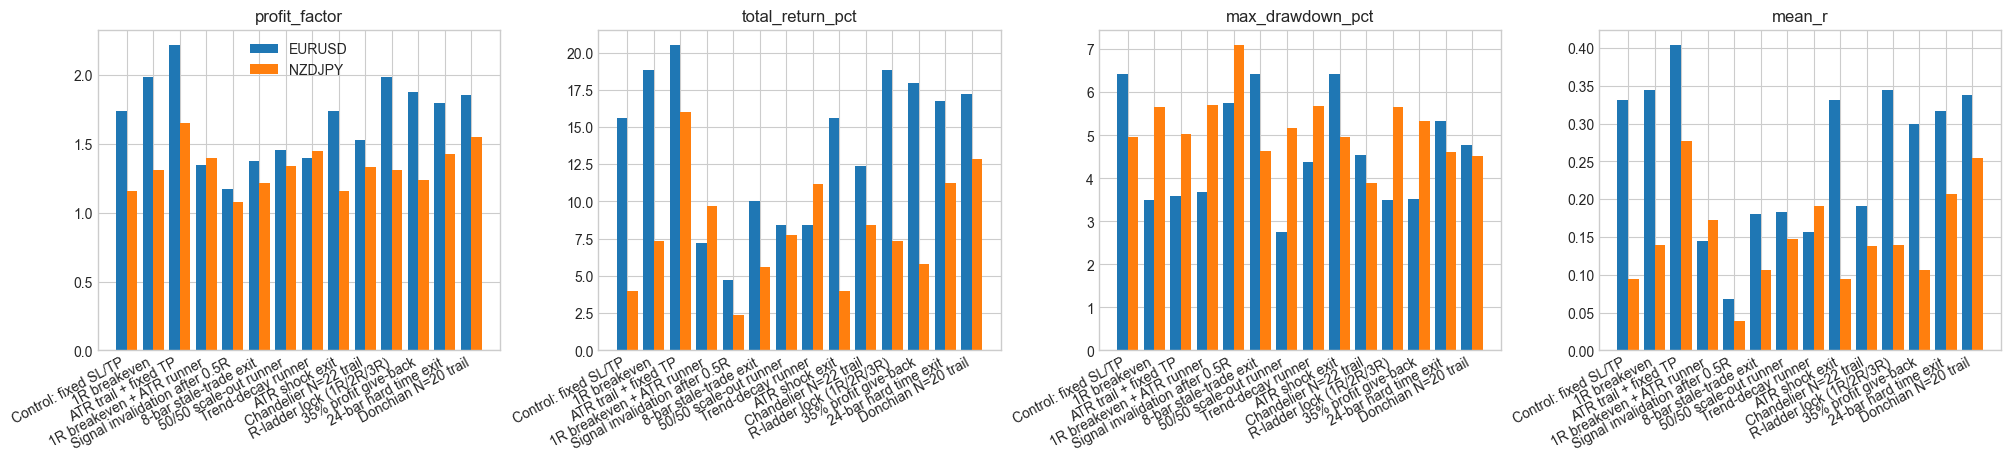

In [3]:
study_payloads = {
    symbol: load_symbol_payload(symbol, BASELINE_STRATEGY_NAME, BASELINE_PARAMS, TIMEFRAME, BAR_COUNT)
    for symbol in SYMBOLS
}

official_results = {}
managed_results = {}
parity_rows = []
strategy_rows = []

for symbol, payload in study_payloads.items():
    official = run_official_baseline(payload, pipeline_config)
    control = run_managed_replay(payload, "control_fixed", pipeline_config)
    official_results[symbol] = official
    managed_results[(symbol, "control_fixed")] = control
    parity_rows.append(
        {
            "symbol": symbol,
            "official_trades": official.get("total_trades", 0),
            "control_trades": control.get("total_trades", 0),
            "trade_delta": control.get("total_trades", 0) - official.get("total_trades", 0),
            "official_pf": official.get("profit_factor", 0.0),
            "control_pf": control.get("profit_factor", 0.0),
            "pf_delta": control.get("profit_factor", 0.0) - official.get("profit_factor", 0.0),
            "official_return_pct": official.get("total_return_pct", 0.0),
            "control_return_pct": control.get("total_return_pct", 0.0),
            "return_delta_pct": control.get("total_return_pct", 0.0) - official.get("total_return_pct", 0.0),
            "official_dd_pct": official.get("max_drawdown_pct", 0.0),
            "control_dd_pct": control.get("max_drawdown_pct", 0.0),
            "dd_delta_pct": control.get("max_drawdown_pct", 0.0) - official.get("max_drawdown_pct", 0.0),
        }
    )
    for arm_name in ARM_POLICIES:
        if arm_name != "control_fixed":
            managed_results[(symbol, arm_name)] = run_managed_replay(payload, arm_name, pipeline_config)
        strategy_rows.append(extract_core_metrics(managed_results[(symbol, arm_name)], symbol, arm_name))

parity_df = pd.DataFrame(parity_rows)
display(Markdown("## Control-arm parity check"))
display(parity_df)

parity_max_abs = parity_df[["trade_delta", "pf_delta", "return_delta_pct", "dd_delta_pct"]].abs().to_numpy().max()
if parity_max_abs > 1e-8:
    raise AssertionError("Custom control arm diverged from the official FXPM baseline.")

strategy_results_df = pd.DataFrame(strategy_rows).sort_values(["symbol", "arm"]).reset_index(drop=True)
display(Markdown("## Strategy results by order-management arm"))
display(strategy_results_df)

delta_df = make_delta_vs_control(strategy_results_df)
display(Markdown("## Delta vs fixed-SL/TP control"))
display(
    delta_df[
        [
            "symbol",
            "arm",
            "delta_profit_factor",
            "delta_total_return_pct",
            "delta_max_drawdown_pct",
            "delta_expectancy_pips",
            "delta_mean_r",
        ]
    ]
)

plot_metric_panels(strategy_results_df, ["profit_factor", "total_return_pct", "max_drawdown_pct", "mean_r"])


## Random-entry sanity-control design

Only price-path-based overlays are tested here. Arms that use the baseline strategy's support state (`signal_invalidation_exit`, `trend_decay_runner`) are intentionally excluded because that would leak model-state information into the random control.

## Random-entry raw metric summary

profit_factor               total_return_pct                max_drawdown_pct                 mean_r               
                                        mean    std median             mean    std  median             mean    std  median    mean    std  median
symbol arm                                                                                                                                       
EURUSD atr_trail_capped               0.9200 0.1783 0.9100          -3.0828 6.2540 -2.9950          11.3505 3.8216 11.3400 -0.0428 0.0967 -0.0410
       be_plus_atr_runner             0.8062 0.1779 0.7700          -6.0078 5.5971 -6.5650          12.2870 4.0159 12.3450 -0.0987 0.0969 -0.1060
       breakeven_1r                   0.9232 0.1978 0.8600          -2.9358 6.6018 -4.4300          11.3472 3.7324 10.5150 -0.0424 0.1037 -0.0645
       chandelier_exit                0.9062 0.1875 0.9000          -3.5410 6.5023 -3.3900          11.1538 4.1474 10.7700 -0.0434 0.0875 -0.0415
       control_fixed                  0.9245 0.2275 0.9350          -3.1860 7.7808 -2.2550          11.7938 4.7840 11.5250 -0.0512 0.1392 -0.0330
       donchian_trail                 0.9085 0.1996 0.9700          -3.4050 6.9272 -1.0150          11.5108 3.7871 11.4100 -0.0497 0.1106 -0.0090
       hard_time_exit                 0.9033 0.2111 0.8950          -3.8760 7.7348 -3.8250          11.8828 4.5427 11.7000 -0.0573 0.1228 -0.0520
       profit_giveback_exit           0.8875 0.1884 0.8850          -4.4605 6.9426 -4.1900          11.9535 4.2666 11.8300 -0.0629 0.1009 -0.0535
       r_ladder_lock                  0.9232 0.1978 0.8600          -2.9358 6.6018 -4.4300          11.3472 3.7324 10.5150 -0.0424 0.1037 -0.0645
       stagnation_time_stop           0.9612 0.2679 0.9600          -2.0790 8.7982 -1.3750          11.5402 4.9403 10.6900 -0.0289 0.1440 -0.0165
       two_leg_scaleout_runner        0.8822 0.2289 0.8950          -3.8298 6.2668 -2.8350          10.1450 4.0598  9.1150 -0.0680 0.1191 -0.0465
       volatility_shock_exit          0.9172 0.2201 0.9350          -3.3890 7.6028 -2.2700          11.7882 4.7656 11.5250 -0.0546 0.1358 -0.0315
NZDJPY atr_trail_capped               0.9108 0.2570 0.8450          -3.3735 7.9867 -4.7550          10.9302 4.7106 10.0150 -0.0537 0.1314 -0.0740
       be_plus_atr_runner             0.9488 0.3599 0.8850          -2.3617 8.9012 -2.9700          10.1410 3.7472  9.2500 -0.0373 0.1676 -0.0500
       breakeven_1r                   0.9085 0.2630 0.8700          -3.3725 7.5773 -4.1600          10.6150 3.9510 10.0800 -0.0557 0.1293 -0.0670
       chandelier_exit                0.9595 0.2462 0.9100          -1.7548 7.6350 -2.5800           9.8322 4.0398  8.7950 -0.0233 0.1078 -0.0330
       control_fixed                  0.9258 0.2745 0.9000          -3.0792 8.5760 -3.2600          11.4262 4.6517 10.4650 -0.0556 0.1632 -0.0540
       donchian_trail                 1.0000 0.3205 0.9600          -1.0242 8.9180 -1.2750           9.9362 4.3845  9.2800 -0.0133 0.1477 -0.0150
       hard_time_exit                 0.9100 0.2695 0.8700          -3.5565 8.5323 -4.1700          11.3872 5.0767 10.6300 -0.0580 0.1463 -0.0660
       profit_giveback_exit           0.8508 0.2178 0.8450          -5.2905 7.1816 -5.3100          11.3600 4.3133 10.5000 -0.0806 0.1112 -0.0750
       r_ladder_lock                  0.9085 0.2630 0.8700          -3.3725 7.5773 -4.1600          10.6150 3.9510 10.0800 -0.0557 0.1293 -0.0670
       stagnation_time_stop           0.9205 0.2688 0.8850          -3.1978 8.4288 -3.6750          11.3595 4.3592 10.3700 -0.0515 0.1438 -0.0555
       two_leg_scaleout_runner        0.9402 0.2929 0.8800          -2.2938 6.8831 -2.8800           8.7570 3.3531  8.5550 -0.0400 0.1387 -0.0550
       volatility_shock_exit          0.9245 0.2780 0.9100          -3.1432 8.6701 -2.7800          11.5430 4.5887 10.4650 -0.0563 0.1641 -0.0470

## Random-entry uplift summary vs fixed control

delta_profit_factor                delta_total_return_pct                delta_max_drawdown_pct                delta_mean_r               
                                              mean    std  median                   mean    std  median                   mean    std  median         mean    std  median
symbol arm                                                                                                                                                               
EURUSD atr_trail_capped                    -0.0045 0.1338  0.0100                 0.1033 4.5779  0.2150                 0.4433 3.0033  0.1000       0.0084 0.0846  0.0155
       be_plus_atr_runner                  -0.1182 0.1958 -0.1100                -2.8217 6.5891 -2.9100                -0.4932 3.6096 -0.7350      -0.0475 0.1175 -0.0520
       breakeven_1r                        -0.0013 0.1377  0.0000                 0.2502 4.6942 -0.0000                 0.4465 3.0005  0.0900       0.0088 0.0843  0.0030
       chandelier_exit                     -0.0183 0.2215 -0.0400                -0.3550 7.4510 -0.6200                 0.6400 4.3296  0.3050       0.0078 0.1257  0.0195
       donchian_trail                      -0.0160 0.1584 -0.0350                -0.2190 5.5009 -1.0800                 0.2830 3.6029  0.1000       0.0015 0.0966 -0.0125
       hard_time_exit                      -0.0213 0.1147 -0.0350                -0.6900 3.9858 -1.1150                -0.0890 2.0752 -0.1900      -0.0061 0.0706 -0.0115
       profit_giveback_exit                -0.0370 0.1573 -0.0450                -1.2745 5.7533 -1.9000                -0.1598 3.4647 -0.2100      -0.0117 0.0978 -0.0110
       r_ladder_lock                       -0.0013 0.1377  0.0000                 0.2502 4.6942 -0.0000                 0.4465 3.0005  0.0900       0.0088 0.0843  0.0030
       stagnation_time_stop                 0.0368 0.1287  0.0500                 1.1070 4.3915  1.8900                 0.2535 2.2633 -0.0200       0.0223 0.0720  0.0320
       two_leg_scaleout_runner             -0.0422 0.2472 -0.0500                -0.6437 7.6757 -1.1250                 1.6487 4.5178  0.9450      -0.0168 0.1388 -0.0220
       volatility_shock_exit               -0.0072 0.0349  0.0000                -0.2030 1.0226  0.0000                 0.0055 0.2410  0.0000      -0.0034 0.0181  0.0000
NZDJPY atr_trail_capped                    -0.0150 0.1621 -0.0150                -0.2942 4.8240 -0.4500                 0.4960 3.0016  0.1200       0.0019 0.0903  0.0045
       be_plus_atr_runner                   0.0230 0.2528  0.0000                 0.7175 6.9747  0.8500                 1.2852 3.7720  0.8900       0.0183 0.1345  0.0235
       breakeven_1r                        -0.0172 0.1349  0.0000                -0.2932 4.1337  0.1350                 0.8112 2.5670  0.9300      -0.0001 0.0787  0.0125
       chandelier_exit                      0.0338 0.2055  0.0550                 1.3245 6.7522  1.7700                 1.5940 4.7699  1.6100       0.0323 0.1235  0.0300
       donchian_trail                       0.0743 0.2009  0.0850                 2.0550 5.5751  2.5650                 1.4900 3.4539  1.4600       0.0423 0.0981  0.0505
       hard_time_exit                      -0.0157 0.1630  0.0200                -0.4773 5.1655  0.4300                 0.0390 2.7228  0.2400      -0.0024 0.0938  0.0115
       profit_giveback_exit                -0.0750 0.1623 -0.0600                -2.2112 5.2432 -1.8450                 0.0663 2.9011 -0.3750      -0.0250 0.1012 -0.0235
       r_ladder_lock                       -0.0172 0.1349  0.0000                -0.2932 4.1337  0.1350                 0.8112 2.5670  0.9300      -0.0001 0.0787  0.0125
       stagnation_time_stop                -0.0052 0.1209  0.0100                -0.1185 3.9405  0.2100                 0.0668 2.5921 -0.0650       0.0041 0.0714 -0.0010
       two_leg_scaleout_runner              0.0145 0.2247  0.0250                 0.7855 6.6556  1.1400                 2

## Strategy uplift vs random-entry uplift distribution

,symbol,arm,strategy_pf_delta,random_pf_delta_mean,strategy_pf_delta_percentile,strategy_pf_delta_p_right,strategy_return_delta_pct,random_return_delta_mean,strategy_return_delta_percentile,strategy_return_delta_p_right,strategy_dd_improvement_pct,random_dd_improvement_mean,strategy_dd_improvement_percentile
0,EURUSD,breakeven_1r,0.2500,-0.0013,95.0000,0.0500,3.2200,0.2502,75.0000,0.2500,2.9300,0.4465,80.0000
1,EURUSD,atr_trail_capped,0.4800,-0.0045,100.0000,0.0000,4.8700,0.1033,85.0000,0.1500,2.8500,0.4433,77.5000
2,EURUSD,be_plus_atr_runner,-0.3900,-0.1182,7.5000,0.9250,-8.4400,-2.8218,22.5000,0.7750,2.7500,-0.4932,82.5000
3,EURUSD,stagnation_time_stop,-0.3600,0.0368,0.0000,1.0000,-5.6000,1.1070,7.5000,0.9250,0.0000,0.2535,52.5000
4,EURUSD,two_leg_scaleout_runner,-0.2800,-0.0422,15.0000,0.8500,-7.2100,-0.6438,22.5000,0.7750,3.6800,1.6487,75.0000
5,EURUSD,volatility_shock_exit,0.0000,-0.0072,80.0000,0.8000,0.0000,-0.2030,65.0000,0.8000,0.0000,0.0055,82.5000
6,EURUSD,chandelier_exit,-0.2100,-0.0183,17.5000,0.8250,-3.2500,-0.3550,42.5000,0.5750,1.8900,0.6400,67.5000
7,EURUSD,r_ladder_lock,0.2500,-0.0013,95.0000,0.0500,3.2200,0.2502,75.0000,0.2500,2.9300,0.4465,80.0000
8,EURUSD,profit_giveback_exit,0.1400,-0.0370,85.0000,0.1500,2.3200,-1.2745,72.5000,0.2750,2.9200,-0.1598,85.0000
9,EURUSD,hard_time_exit,0.0600,-0.0213,82.5000,0.2000,1.1300,-0.6900,67.5000,0.3250,1.0900,-0.0890,67.5000


C:\Users\Bongo\AppData\Local\Temp\ipykernel_17896\2471662094.py:108: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_data, labels=labels, showfliers=False)


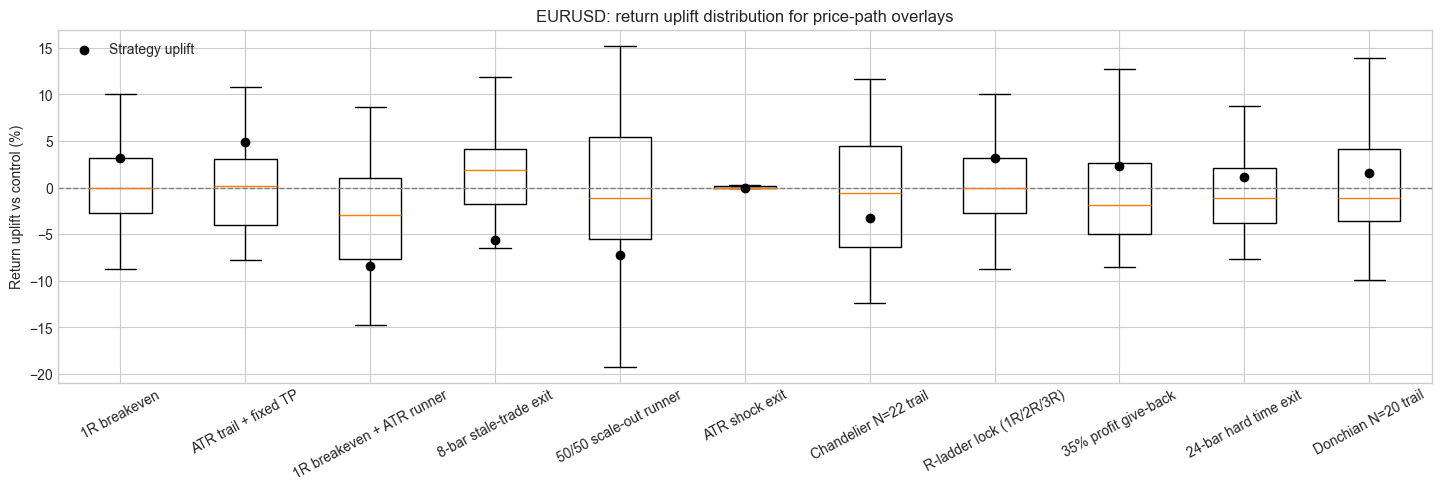

C:\Users\Bongo\AppData\Local\Temp\ipykernel_17896\2471662094.py:108: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_data, labels=labels, showfliers=False)


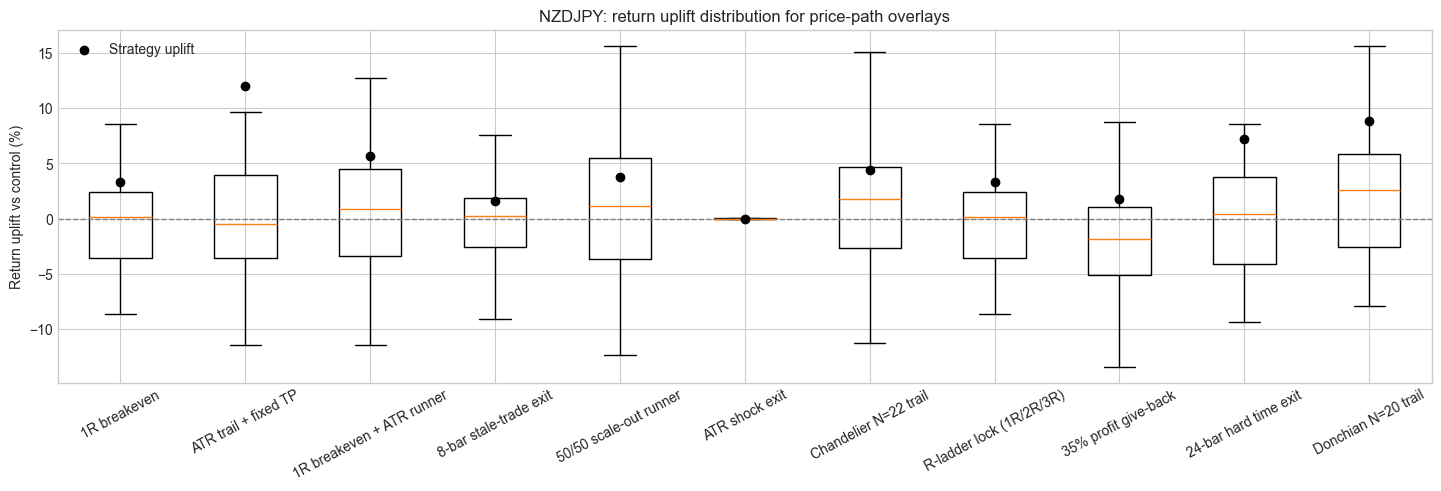

In [4]:
display(
    Markdown(
        "## Random-entry sanity-control design\n\n"
        "Only price-path-based overlays are tested here. Arms that use the baseline strategy's support state "
        "(`signal_invalidation_exit`, `trend_decay_runner`) are intentionally excluded because that would leak "
        "model-state information into the random control."
    )
)

random_metric_rows = []
random_uplift_rows = []

for symbol, payload in study_payloads.items():
    for seed in RANDOM_SEEDS:
        random_signals = make_random_signals_like(payload["signals"], payload["warmup_bars"], seed)
        random_payload = dict(payload)
        random_payload["signals"] = random_signals
        random_control = run_managed_replay(random_payload, "control_fixed", pipeline_config)

        random_metric_rows.append(
            {
                "symbol": symbol,
                "seed": seed,
                "arm": "control_fixed",
                "profit_factor": random_control.get("profit_factor", 0.0),
                "total_return_pct": random_control.get("total_return_pct", 0.0),
                "max_drawdown_pct": random_control.get("max_drawdown_pct", 0.0),
                "mean_r": random_control.get("mean_r", 0.0),
            }
        )

        for arm_name in RANDOM_TEST_ARMS:
            random_arm = run_managed_replay(random_payload, arm_name, pipeline_config)
            random_metric_rows.append(
                {
                    "symbol": symbol,
                    "seed": seed,
                    "arm": arm_name,
                    "profit_factor": random_arm.get("profit_factor", 0.0),
                    "total_return_pct": random_arm.get("total_return_pct", 0.0),
                    "max_drawdown_pct": random_arm.get("max_drawdown_pct", 0.0),
                    "mean_r": random_arm.get("mean_r", 0.0),
                }
            )
            random_uplift_rows.append(
                {
                    "symbol": symbol,
                    "seed": seed,
                    "arm": arm_name,
                    "delta_profit_factor": random_arm.get("profit_factor", 0.0) - random_control.get("profit_factor", 0.0),
                    "delta_total_return_pct": random_arm.get("total_return_pct", 0.0) - random_control.get("total_return_pct", 0.0),
                    "delta_max_drawdown_pct": random_control.get("max_drawdown_pct", 0.0) - random_arm.get("max_drawdown_pct", 0.0),
                    "delta_mean_r": random_arm.get("mean_r", 0.0) - random_control.get("mean_r", 0.0),
                }
            )

random_metric_df = pd.DataFrame(random_metric_rows)
random_summary_df = (
    random_metric_df.groupby(["symbol", "arm"])[["profit_factor", "total_return_pct", "max_drawdown_pct", "mean_r"]]
    .agg(["mean", "std", "median"])
    .round(4)
)
display(Markdown("## Random-entry raw metric summary"))
display(random_summary_df)

random_uplift_df = pd.DataFrame(random_uplift_rows)
random_uplift_summary_df = (
    random_uplift_df.groupby(["symbol", "arm"])[["delta_profit_factor", "delta_total_return_pct", "delta_max_drawdown_pct", "delta_mean_r"]]
    .agg(["mean", "std", "median"])
    .round(4)
)
display(Markdown("## Random-entry uplift summary vs fixed control"))
display(random_uplift_summary_df)

actual_price_path_delta_df = delta_df[delta_df["arm"].isin(RANDOM_TEST_ARMS)].copy()
comparison_rows = []
for symbol in SYMBOLS:
    for arm_name in RANDOM_TEST_ARMS:
        dist = random_uplift_df[(random_uplift_df["symbol"] == symbol) & (random_uplift_df["arm"] == arm_name)]
        actual = actual_price_path_delta_df[(actual_price_path_delta_df["symbol"] == symbol) & (actual_price_path_delta_df["arm"] == arm_name)].iloc[0]
        comparison_rows.append(
            {
                "symbol": symbol,
                "arm": arm_name,
                "strategy_pf_delta": actual["delta_profit_factor"],
                "random_pf_delta_mean": dist["delta_profit_factor"].mean(),
                "strategy_pf_delta_percentile": (dist["delta_profit_factor"] <= actual["delta_profit_factor"]).mean() * 100.0,
                "strategy_pf_delta_p_right": (dist["delta_profit_factor"] >= actual["delta_profit_factor"]).mean(),
                "strategy_return_delta_pct": actual["delta_total_return_pct"],
                "random_return_delta_mean": dist["delta_total_return_pct"].mean(),
                "strategy_return_delta_percentile": (dist["delta_total_return_pct"] <= actual["delta_total_return_pct"]).mean() * 100.0,
                "strategy_return_delta_p_right": (dist["delta_total_return_pct"] >= actual["delta_total_return_pct"]).mean(),
                "strategy_dd_improvement_pct": actual["delta_max_drawdown_pct"],
                "random_dd_improvement_mean": dist["delta_max_drawdown_pct"].mean(),
                "strategy_dd_improvement_percentile": (dist["delta_max_drawdown_pct"] <= actual["delta_max_drawdown_pct"]).mean() * 100.0,
            }
        )

random_vs_strategy_df = pd.DataFrame(comparison_rows).round(4)
display(Markdown("## Strategy uplift vs random-entry uplift distribution"))
display(random_vs_strategy_df)

for symbol in SYMBOLS:
    fig, ax = plt.subplots(figsize=(max(8, 1.3 * len(RANDOM_TEST_ARMS)), 4.8), constrained_layout=True)
    symbol_slice = random_uplift_df[random_uplift_df["symbol"] == symbol]
    box_data = [symbol_slice[symbol_slice["arm"] == arm_name]["delta_total_return_pct"].to_numpy() for arm_name in RANDOM_TEST_ARMS]
    labels = [ARM_POLICIES[arm_name]["label"] for arm_name in RANDOM_TEST_ARMS]
    ax.boxplot(box_data, labels=labels, showfliers=False)
    strategy_points = [
        actual_price_path_delta_df[
            (actual_price_path_delta_df["symbol"] == symbol) & (actual_price_path_delta_df["arm"] == arm_name)
        ]["delta_total_return_pct"].iloc[0]
        for arm_name in RANDOM_TEST_ARMS
    ]
    ax.scatter(np.arange(1, len(RANDOM_TEST_ARMS) + 1), strategy_points, color="black", zorder=3, label="Strategy uplift")
    ax.axhline(0.0, color="gray", linestyle="--", linewidth=1)
    ax.set_title(f"{symbol}: return uplift distribution for price-path overlays")
    ax.set_ylabel("Return uplift vs control (%)")
    ax.tick_params(axis="x", rotation=28)
    ax.legend()
    plt.show()


## Per-arm exit-reason / MFE / MAE diagnostics

,symbol,arm,arm_label,n_trades,mean_mfe_r,mean_mae_r,median_bars_held,top_exit_reason
0,EURUSD,control_fixed,Control: fixed SL/TP,45,0.9320,0.6060,14.0000,CLOSED_TP
1,EURUSD,breakeven_1r,1R breakeven,51,0.9210,0.5310,14.0000,CLOSED_TP
2,EURUSD,atr_trail_capped,ATR trail + fixed TP,47,0.9380,0.5650,14.0000,CLOSED_TP
3,EURUSD,be_plus_atr_runner,1R breakeven + ATR runner,50,1.2020,0.5320,17.0000,ATR_TRAIL_STOP
4,EURUSD,signal_invalidation_exit,Signal invalidation after 0.5R,73,0.7340,0.4940,7.0000,SIGNAL_INVALIDATION_EXIT
5,EURUSD,stagnation_time_stop,8-bar stale-trade exit,55,0.7940,0.5710,8.0000,CLOSED_TP
6,EURUSD,two_leg_scaleout_runner,50/50 scale-out runner,94,0.9810,0.3320,14.0000,FIXED_SL
7,EURUSD,trend_decay_runner,Trend-decay runner,54,1.1840,0.5320,15.5000,FIXED_SL
8,EURUSD,volatility_shock_exit,ATR shock exit,45,0.9320,0.6060,14.0000,CLOSED_TP
9,EURUSD,chandelier_exit,Chandelier N=22 trail,63,0.7790,0.4760,7.0000,CHANDELIER_STOP


### Full exit-reason crosstab

exit_reason                      ATR_TRAIL_STOP  BREAKEVEN_STOP  CHANDELIER_STOP  CLOSED_EOD  CLOSED_TP  DONCHIAN_STOP  FIXED_SL  GIVEBACK_STOP  HARD_TIME_EXIT  \
symbol arm                                                                                                                                                        
EURUSD atr_trail_capped                       8               0                0           1         23              0        15              0               0   
       be_plus_atr_runner                    21               3                0           1          5              0        20              0               0   
       breakeven_1r                           0               9                0           1         24              0        17              0               0   
       chandelier_exit                        0               0               23           1         22              0        17              0               0   
       control_fixed                          0               0                0           1         24              0        20              0               0   
       donchian_trail                         0               0                0           1         24              9        14              0               0   
       hard_time_exit                         0               0                0           1         21              0        18              0              10   
       profit_giveback_exit                   0               0                0           1         15              0        19             21               0   
       r_ladder_lock                          0               9                0           1         24              0        17              0               0   
       signal_invalidation_exit               0               0                0           1         20              0        23              0               0   
       stagnation_time_stop                   0               0                0           1         24              0        23              0               0   
       trend_decay_runner                    15               3                0           1          4              0        20              0               0   
       two_leg_scaleout_runner               28               2                0           2         26              0        36              0               0   
       volatility_shock_exit                  0               0                0           1         24              0        20              0               0   
NZDJPY atr_trail_capped                       8               0                0           0         25              0        22              0               0   
       be_plus_atr_runner                    24               4                0           0          6              0        22              0               0   
       breakeven_1r                           0               9                0           0         21              0        23              0               0   
       chandelier_exit                        0               0               21           0         20              0        20              0               0   
       control_fixed                          0               0                0           0         20              0        25              0               0   
       donchian_trail                         0               0                0           0         23             10        16              0               0   
       hard_time_exit                         0               0                0           0         21              0        23              0               9   
       profit_giveback_exit                   0               0                0           0         11              0        24             21               0   
       r_ladder_lock                          0               9                0        

## Bootstrap 95% CI on mean R per (symbol, arm)

,symbol,arm,arm_label,n_trades,mean_r,r_ci_low_95,r_ci_high_95,ci_excludes_zero
0,EURUSD,atr_trail_capped,ATR trail + fixed TP,47,0.4040,0.0840,0.7230,True
1,EURUSD,be_plus_atr_runner,1R breakeven + ATR runner,50,0.1450,-0.1520,0.4550,False
2,EURUSD,breakeven_1r,1R breakeven,51,0.3450,0.0430,0.6400,True
3,EURUSD,chandelier_exit,Chandelier N=22 trail,63,0.1910,-0.0620,0.4450,False
4,EURUSD,control_fixed,Control: fixed SL/TP,45,0.3310,-0.0170,0.6800,False
5,EURUSD,donchian_trail,Donchian N=20 trail,48,0.3380,0.0170,0.6640,True
6,EURUSD,hard_time_exit,24-bar hard time exit,50,0.3170,0.0070,0.6360,True
7,EURUSD,profit_giveback_exit,35% profit give-back,56,0.3000,0.0460,0.5510,True
8,EURUSD,r_ladder_lock,R-ladder lock (1R/2R/3R),51,0.3450,0.0430,0.6400,True
9,EURUSD,signal_invalidation_exit,Signal invalidation after 0.5R,73,0.0680,-0.1590,0.2930,False


## Edge-retention score (strategy uplift minus mean random-entry uplift)

,symbol,arm,arm_label,strategy_return_uplift_pct,random_return_uplift_mean_pct,edge_retention_pct,edge_z_vs_random
0,EURUSD,atr_trail_capped,ATR trail + fixed TP,4.8700,0.1030,4.7670,1.0410
1,EURUSD,profit_giveback_exit,35% profit give-back,2.3200,-1.2740,3.5950,0.6250
2,EURUSD,breakeven_1r,1R breakeven,3.2200,0.2500,2.9700,0.6330
3,EURUSD,r_ladder_lock,R-ladder lock (1R/2R/3R),3.2200,0.2500,2.9700,0.6330
4,EURUSD,hard_time_exit,24-bar hard time exit,1.1300,-0.6900,1.8200,0.4570
5,EURUSD,donchian_trail,Donchian N=20 trail,1.5800,-0.2190,1.7990,0.3270
6,EURUSD,volatility_shock_exit,ATR shock exit,0.0000,-0.2030,0.2030,0.1990
7,EURUSD,chandelier_exit,Chandelier N=22 trail,-3.2500,-0.3550,-2.8950,-0.3890
8,EURUSD,be_plus_atr_runner,1R breakeven + ATR runner,-8.4400,-2.8220,-5.6180,-0.8530
9,EURUSD,two_leg_scaleout_runner,50/50 scale-out runner,-7.2100,-0.6440,-6.5660,-0.8550


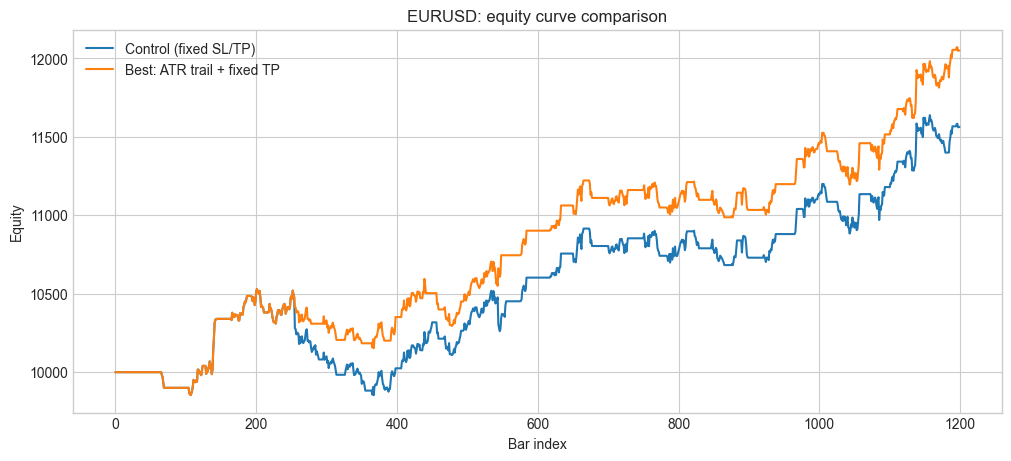

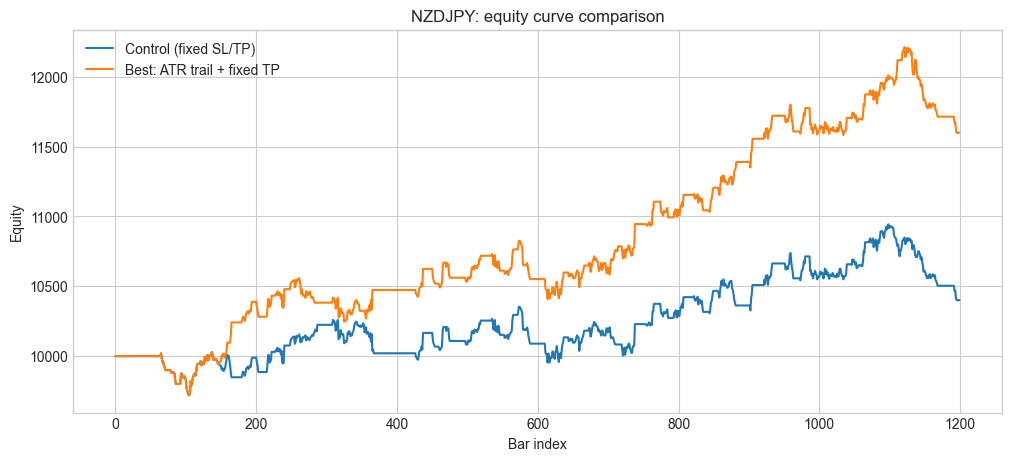

In [5]:
# =============================================================================
# Enriched diagnostics
# =============================================================================
# This cell exposes three diagnostics that live behind the headline metrics:
#
# 1. Per-arm exit-reason breakdown with mean MFE and mean MAE in R units.
#    This is the clearest sanity check on "did the overlay actually do what
#    it claims to do?" - for example, an ATR trail arm should show most exits
#    tagged as ATR_TRAIL_STOP, with mean MFE meaningfully above mean MAE.
#
# 2. Bootstrap 95% percentile CI on per-trade R for each (symbol, arm). This
#    quantifies how much of the observed uplift is sample-size noise.
#
# 3. Edge-retention score: strategy return uplift minus mean random-entry
#    return uplift, in percent. Values near zero indicate the overlay is a
#    generic reshaping mechanism rather than signal-aware edge preservation.
# =============================================================================

all_arm_names = list(ARM_POLICIES.keys())
trade_diag_df = summarize_trade_diagnostics(managed_results, all_arm_names)
display(Markdown("## Per-arm exit-reason / MFE / MAE diagnostics"))
display(trade_diag_df.drop(columns=["exit_reasons"]))

exit_reason_rows = []
for _, row in trade_diag_df.iterrows():
    reasons = row.get("exit_reasons", {}) or {}
    for reason, count in reasons.items():
        exit_reason_rows.append(
            {
                "symbol": row["symbol"],
                "arm": row["arm"],
                "arm_label": row["arm_label"],
                "exit_reason": reason,
                "count": int(count),
            }
        )
exit_reason_df = (
    pd.DataFrame(exit_reason_rows)
    .pivot_table(index=["symbol", "arm"], columns="exit_reason", values="count", fill_value=0)
    .astype(int)
    if exit_reason_rows
    else pd.DataFrame()
)
display(Markdown("### Full exit-reason crosstab"))
display(exit_reason_df)

bootstrap_rows = []
for (symbol, arm_name), result in managed_results.items():
    r_values = np.array([float(t.get("r_multiple", 0.0)) for t in (result.get("trades") or [])])
    mean_r, lo, hi = bootstrap_mean_ci(r_values)
    bootstrap_rows.append(
        {
            "symbol": symbol,
            "arm": arm_name,
            "arm_label": ARM_POLICIES[arm_name]["label"],
            "n_trades": int(r_values.size),
            "mean_r": round(mean_r, 3) if np.isfinite(mean_r) else mean_r,
            "r_ci_low_95": round(lo, 3) if np.isfinite(lo) else lo,
            "r_ci_high_95": round(hi, 3) if np.isfinite(hi) else hi,
            "ci_excludes_zero": bool(np.isfinite(lo) and np.isfinite(hi) and (lo > 0.0 or hi < 0.0)),
        }
    )
bootstrap_df = pd.DataFrame(bootstrap_rows).sort_values(["symbol", "arm"]).reset_index(drop=True)
display(Markdown("## Bootstrap 95% CI on mean R per (symbol, arm)"))
display(bootstrap_df)

# Edge-retention score: strategy uplift minus mean random uplift (return pct).
edge_rows = []
for symbol in SYMBOLS:
    for arm_name in RANDOM_TEST_ARMS:
        actual = delta_df[(delta_df["symbol"] == symbol) & (delta_df["arm"] == arm_name)].iloc[0]
        random_mean = random_uplift_df[
            (random_uplift_df["symbol"] == symbol) & (random_uplift_df["arm"] == arm_name)
        ]["delta_total_return_pct"].mean()
        random_std = random_uplift_df[
            (random_uplift_df["symbol"] == symbol) & (random_uplift_df["arm"] == arm_name)
        ]["delta_total_return_pct"].std(ddof=1)
        edge = float(actual["delta_total_return_pct"] - random_mean)
        z_vs_random = float((actual["delta_total_return_pct"] - random_mean) / random_std) if random_std and np.isfinite(random_std) else float("nan")
        edge_rows.append(
            {
                "symbol": symbol,
                "arm": arm_name,
                "arm_label": ARM_POLICIES[arm_name]["label"],
                "strategy_return_uplift_pct": round(float(actual["delta_total_return_pct"]), 3),
                "random_return_uplift_mean_pct": round(float(random_mean), 3),
                "edge_retention_pct": round(edge, 3),
                "edge_z_vs_random": round(z_vs_random, 3) if np.isfinite(z_vs_random) else z_vs_random,
            }
        )
edge_df = pd.DataFrame(edge_rows).sort_values(["symbol", "edge_retention_pct"], ascending=[True, False]).reset_index(drop=True)
display(Markdown("## Edge-retention score (strategy uplift minus mean random-entry uplift)"))
display(edge_df)

# Equity curve overlay (control vs best arm per symbol for a quick visual sanity check).
for symbol in SYMBOLS:
    symbol_results = {arm: managed_results[(symbol, arm)] for arm in ARM_POLICIES if (symbol, arm) in managed_results}
    if not symbol_results:
        continue
    best_arm_name = max(
        symbol_results.items(),
        key=lambda kv: (kv[1].get("profit_factor", 0.0), kv[1].get("total_return_pct", 0.0)),
    )[0]
    fig, ax = plt.subplots(figsize=(10, 4.5), constrained_layout=True)
    control_curve = symbol_results["control_fixed"].get("equity_curve", [])
    best_curve = symbol_results[best_arm_name].get("equity_curve", [])
    ax.plot(control_curve, label="Control (fixed SL/TP)")
    ax.plot(best_curve, label=f"Best: {ARM_POLICIES[best_arm_name]['label']}")
    ax.set_title(f"{symbol}: equity curve comparison")
    ax.set_xlabel("Bar index")
    ax.set_ylabel("Equity")
    ax.legend()
    plt.show()


In [6]:
summary_lines = [
    "## Decision summary",
    "",
    "Interpretation guide:",
    "- The control-arm parity table should remain exact. If it is not, the managed replay is not trustworthy.",
    "- Price-path overlays that beat both the fixed control and their random-entry uplift distribution are the cleanest immediate promotion candidates.",
    "- Model-state overlays are still valuable, but they should be interpreted as a controlled extension of the strategy rather than a pure exit-only layer.",
    "- The bootstrap CI on mean R flags arms whose apparent improvement may be driven by a handful of trades.",
    "- The edge-retention score separates real signal-aware exit edge from generic payoff-reshaping that any path-following overlay would also show on random entries.",
    "",
]

for symbol in SYMBOLS:
    symbol_df = strategy_results_df[strategy_results_df["symbol"] == symbol].copy()
    ranked = symbol_df.sort_values(["profit_factor", "total_return_pct", "mean_r"], ascending=[False, False, False])
    best = ranked.iloc[0]
    control = symbol_df[symbol_df["arm"] == "control_fixed"].iloc[0]
    summary_lines.append(
        f"- `{symbol}` best arm in this expanded POC: `{best['arm']}` ({best['arm_label']}). "
        f"PF moved from {control['profit_factor']:.2f} to {best['profit_factor']:.2f}, "
        f"return from {control['total_return_pct']:.2f}% to {best['total_return_pct']:.2f}%, "
        f"and max drawdown from {control['max_drawdown_pct']:.2f}% to {best['max_drawdown_pct']:.2f}%."
    )

# Per-symbol top-3 promotion candidates by edge-retention score.
if not edge_df.empty:
    summary_lines.append("")
    summary_lines.append("Top promotion candidates by edge-retention score (strategy uplift minus mean random uplift):")
    for symbol in SYMBOLS:
        top = edge_df[edge_df["symbol"] == symbol].head(3)
        labels = [f"`{row.arm}` ({row.edge_retention_pct:+.2f}pp)" for row in top.itertuples()]
        summary_lines.append(f"- `{symbol}`: " + ", ".join(labels))

summary_lines.extend(
    [
        "",
        "What to do with the new evidence:",
        "- If `two_leg_scaleout_runner`, `stagnation_time_stop`, `hard_time_exit`, `profit_giveback_exit`, or `chandelier_exit` improve on real signals and do not show the same uplift on random entries, that is strong evidence for broadening FXPM's live governance layer with price-path-only controls first.",
        "- If `signal_invalidation_exit` or `trend_decay_runner` wins, that suggests the best next step is a second-stage architecture where stable entry models get a model-aware post-entry governance overlay.",
        "- If a rule only improves the random-entry controls, treat it as a generic reshaping mechanism rather than true edge preservation and raise the validation bar.",
        "- Scale-out arms record trade legs separately, so trade counts and win rates are not perfectly comparable to single-leg arms; prioritize PF, return, drawdown, and mean R when judging them.",
    ]
)

display(Markdown("\n".join(summary_lines)))


## Decision summary

Interpretation guide:
- The control-arm parity table should remain exact. If it is not, the managed replay is not trustworthy.
- Price-path overlays that beat both the fixed control and their random-entry uplift distribution are the cleanest immediate promotion candidates.
- Model-state overlays are still valuable, but they should be interpreted as a controlled extension of the strategy rather than a pure exit-only layer.
- The bootstrap CI on mean R flags arms whose apparent improvement may be driven by a handful of trades.
- The edge-retention score separates real signal-aware exit edge from generic payoff-reshaping that any path-following overlay would also show on random entries.

- `EURUSD` best arm in this expanded POC: `atr_trail_capped` (ATR trail + fixed TP). PF moved from 1.74 to 2.22, return from 15.64% to 20.51%, and max drawdown from 6.43% to 3.58%.
- `NZDJPY` best arm in this expanded POC: `atr_trail_capped` (ATR trail + fixed TP). PF moved from 1.16 to 1.65, return from 4.01% to 15.99%, and max drawdown from 4.96% to 5.02%.

Top promotion candidates by edge-retention score (strategy uplift minus mean random uplift):
- `EURUSD`: `atr_trail_capped` (+4.77pp), `profit_giveback_exit` (+3.60pp), `breakeven_1r` (+2.97pp)
- `NZDJPY`: `atr_trail_capped` (+12.27pp), `hard_time_exit` (+7.68pp), `donchian_trail` (+6.82pp)

What to do with the new evidence:
- If `two_leg_scaleout_runner`, `stagnation_time_stop`, `hard_time_exit`, `profit_giveback_exit`, or `chandelier_exit` improve on real signals and do not show the same uplift on random entries, that is strong evidence for broadening FXPM's live governance layer with price-path-only controls first.
- If `signal_invalidation_exit` or `trend_decay_runner` wins, that suggests the best next step is a second-stage architecture where stable entry models get a model-aware post-entry governance overlay.
- If a rule only improves the random-entry controls, treat it as a generic reshaping mechanism rather than true edge preservation and raise the validation bar.
- Scale-out arms record trade legs separately, so trade counts and win rates are not perfectly comparable to single-leg arms; prioritize PF, return, drawdown, and mean R when judging them.

## Notes and limitations

- This is a focused proof of concept, not a production promotion test.
- The study intentionally keeps entries fixed and changes only post-entry management.
- Management decisions are causal: each rule can only use completed information from the previous bar. Rolling Chandelier/Donchian levels are `.shift(1)` so bar `i` can only see information through bar `i-1`.
- `signal_invalidation_exit` and `trend_decay_runner` are strategy-aware overlays because they use the baseline model's support state after entry. Same-bar re-entry after a signal-invalidation exit requires the generator signal on the previous bar to have actually flipped to the opposite side; the continuous support state alone is not sufficient.
- `two_leg_scaleout_runner` records each leg as a separate cash-flow leg. That preserves equity arithmetic but makes trade counts and leg-level win rates less directly comparable to single-position arms.
- MFE / MAE are reported in R units and are updated bar-by-bar from the strategy's own post-entry path. They are stored on each closed trade so downstream analysis can compare them against the exit price to quantify exit timing quality.
- The bootstrap CI on mean R is a percentile CI with 1000 resamples. For small trade counts, it is a lower bound on uncertainty, not a p-value.
- The edge-retention score compares strategy-on-real-signals uplift to strategy-on-random-signals uplift, so it is a conservative read of how much of the uplift is genuinely signal-aware.
- The next serious step is to replay the winning overlays across a wider symbol and strategy basket, then promote only the ones that survive broader out-of-sample checks.
